In [ ]:
import pandas as pd
train_url = "https://raw.githubusercontent.com/17m301/BioFuel_YieldPrediction/main/Datasets/Train/Trainset_dataset1.xlsx"
test_yield_url = "https://raw.githubusercontent.com/17m301/BioFuel_YieldPrediction/refs/heads/main/Datasets/Test/Testset_dataset1%20(1).csv"
test_url = "https://raw.githubusercontent.com/17m301/BioFuel_YieldPrediction/main/Datasets/Test/Testset_feature_dataset1.xlsx"

df_train = pd.read_excel(train_url)
df_test = pd.read_excel(test_url)
df_test_feature = pd.read_csv(test_yield_url)
df_train.info()
#df_train.head()
df_test.info()
df_test_feature.info()

Understanding the data

In [3]:
df_train.shape #how big is the data?
df_train.describe()# datatype of each column




,Ash(wt%),FixedCarbon(wt%),Volatiles(wt%),C(wt%),H(wt%),O(wt%),N(wt%),H/C,Cellulose(wt%),Hemicellulose(wt%),Lignin(wt%),T(^C),HeatingRate(^C/min),ParticleSize(mm),FlowRate-Nitrogen(ml/min),yield(wt%)
count,747.000000,747.000000,747.000000,845.000000,835.000000,835.000000,805.000000,835.000000,669.000000,483.000000,510.000000,845.000000,845.000000,845.000000,845.000000,845.000000
mean,5.623498,16.034171,78.342330,49.267011,6.482051,40.598446,2.933221,0.121796,34.156218,27.509151,22.667353,514.674556,65.073373,0.812234,125.177515,40.478817
std,3.778697,8.540413,9.971436,6.705218,1.155756,8.613152,2.551525,0.041311,11.559224,10.709667,11.559443,90.715530,112.020190,0.526874,242.063168,9.902880
min,0.278552,0.107181,10.855927,19.490000,2.410000,10.490000,0.170000,0.100000,5.750000,3.400000,0.800000,300.000000,5.000000,0.100000,0.000000,11.000000
25%,2.332980,11.981198,75.774742,44.820000,5.890000,34.190000,0.920000,0.100000,27.200000,19.400000,15.000000,450.000000,7.000000,0.450000,0.000000,33.000000
50%,5.245536,14.880575,78.747204,47.400000,6.230000,41.630000,2.050000,0.100000,32.060000,25.520000,26.110000,500.000000,20.000000,0.650000,100.000000,40.300000
75%,7.286460,17.114094,83.102511,52.900000,6.735700,48.280000,4.400000,0.100000,43.000000,36.550000,30.100000,550.000000,50.000000,1.000000,100.000000,47.800000
max,40.084388,78.545821,95.984215,79.770000,10.590000,54.120000,9.290000,0.200000,60.270000,51.340000,50.400000,900.000000,800.000000,3.200000,2000.000000,77.200000


Find out Total Missing values of each column

In [ ]:
print(df_train.isnull().sum())
print()
print(df_test.isnull().sum())

In [5]:
print(df_train.duplicated().sum())
#df_train[df_train.duplicated()] # Print the duplicates
df_train.drop_duplicates(inplace=True)
print(df_train.duplicated().sum())

37
0


In [ ]:
!pip install ydata-profiling
from ydata_profiling import ProfileReport
prof=ProfileReport(df_train)
prof.to_file(output_file='output_train.html')
prof=ProfileReport(df_test)
prof.to_file(output_file='output_test.html')
prof=ProfileReport(df_test_feature)
prof.to_file(output_file='output_test_feature.html')

EDA

Univariant Analysis


(array([  5.,  36., 105., 185., 205., 144.,  91.,  35.,   1.,   1.]),
 array([11.  , 17.62, 24.24, 30.86, 37.48, 44.1 , 50.72, 57.34, 63.96,
        70.58, 77.2 ]),
 <BarContainer object of 10 artists>)

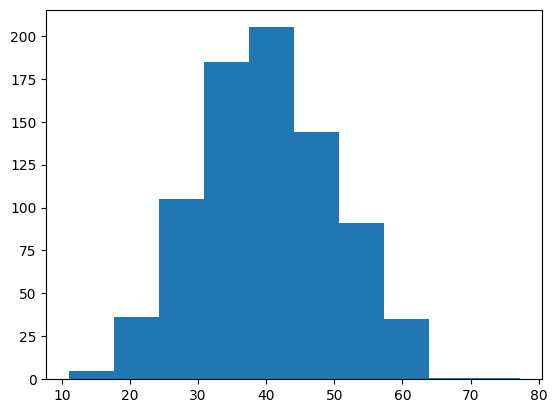

In [7]:
import matplotlib.pyplot as plt
plt.hist(df_train['yield(wt%)'])

# Handling Missing Data

In [47]:
#Using KNN Imputers
from sklearn.impute import KNNImputer
imputer=KNNImputer(n_neighbors=3)
x_train=df_train.drop(columns=['yield(wt%)'])
y_train=df_train['yield(wt%)']
x_train=pd.DataFrame(imputer.fit_transform(x_train),columns=x_train.columns)
x_test=pd.DataFrame(imputer.fit_transform(df_test),columns=df_test.columns)
#df_test_feature=pd.DataFrame(imputer.fit_transform(df_test_feature),columns=df_test_feature.columns)

In [48]:
print(x_train.isnull().sum())
print()
print(x_test.isnull().sum())

Ash(wt%)                     0
FixedCarbon(wt%)             0
Volatiles(wt%)               0
C(wt%)                       0
H(wt%)                       0
O(wt%)                       0
N(wt%)                       0
H/C                          0
Cellulose(wt%)               0
Hemicellulose(wt%)           0
Lignin(wt%)                  0
T(^C)                        0
HeatingRate(^C/min)          0
ParticleSize(mm)             0
FlowRate-Nitrogen(ml/min)    0
dtype: int64

Ash(wt%)                     0
FixedCarbon(wt%)             0
Volatiles(wt%)               0
C(wt%)                       0
H(wt%)                       0
O(wt%)                       0
N(wt%)                       0
H/C                          0
Cellulose(wt%)               0
Hemicellulose(wt%)           0
Lignin(wt%)                  0
T(^C)                        0
HeatingRate(^C/min)          0
ParticleSize(mm)             0
FlowRate-Nitrogen(ml/min)    0
dtype: int64


# Outlier Detection

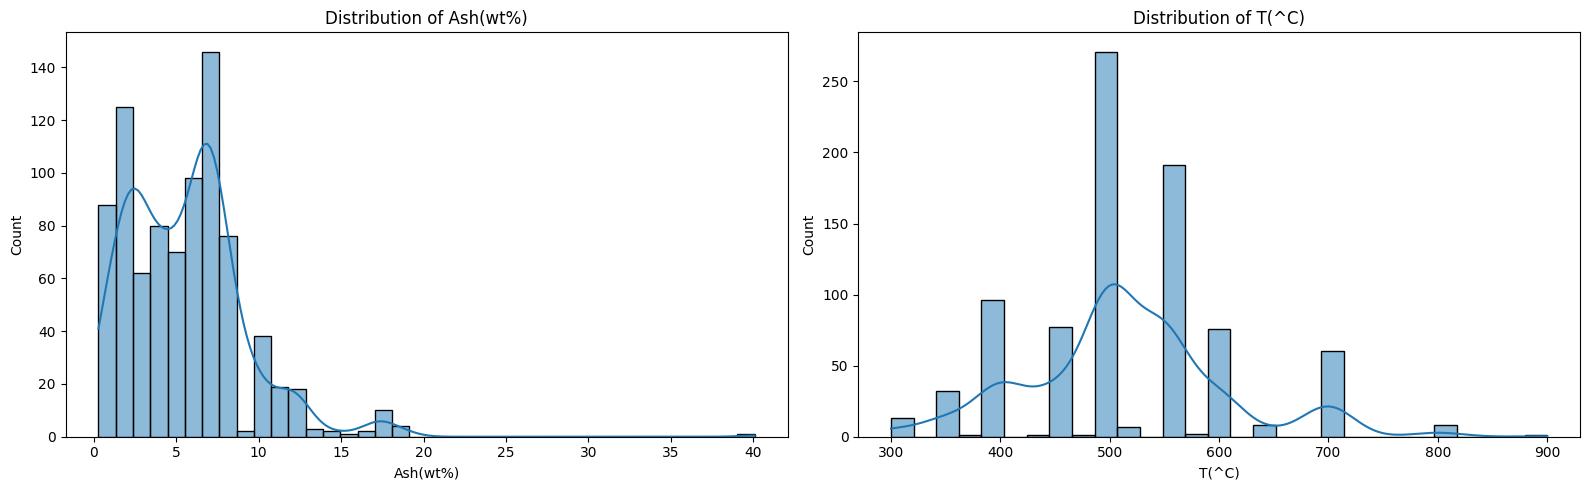

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size for better visibility
plt.figure(figsize=(16, 5))

# Subplot 1
plt.subplot(1, 2, 1)
sns.histplot(x_train['Ash(wt%)'], kde=True)
plt.title('Distribution of Ash(wt%)')

# Subplot 2
plt.subplot(1, 2, 2)
sns.histplot(x_train['T(^C)'], kde=True)
plt.title('Distribution of T(^C)')

plt.tight_layout()
plt.show()

In [11]:
#Normal distribution, Skewed distribution (for skewed data)
#Zscore , IQR based filtering, percentile, Winsorization

#Right Skewed
print(x_train['Ash(wt%)'].skew())
print(x_train['C(wt%)'].skew())
print(x_train['Cellulose(wt%)'].skew())
print(x_train['FixedCarbon(wt%)'].skew())

1.724731987018256
1.1474474168753819
0.07019267499124901
4.755496298749928


Boxplot of each features

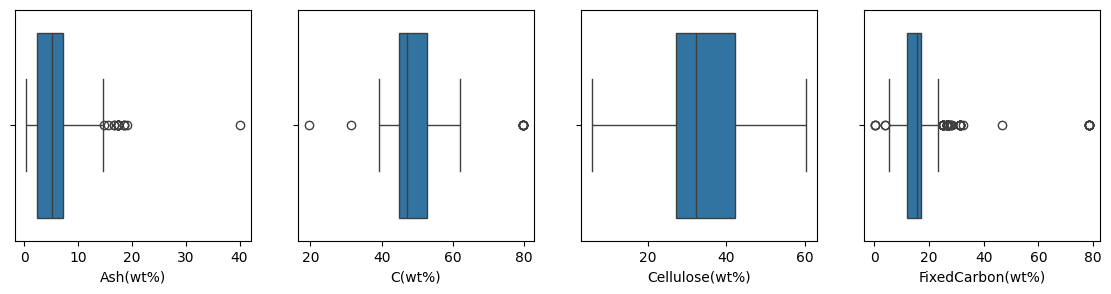

In [12]:
plt.figure(figsize=(14, 3))

plt.subplot(1,4,1)
sns.boxplot(x=x_train['Ash(wt%)'])
plt.subplot(1,4,2)
sns.boxplot(x=x_train['C(wt%)'])
plt.subplot(1,4,3)
sns.boxplot(x=x_train['Cellulose(wt%)'])
plt.subplot(1,4,4)
sns.boxplot(x=x_train['FixedCarbon(wt%)'])
plt.show()


Finding the IQR for each feature


In [50]:
from numpy import percentile

# Dictionary to store outlier counts
outlier_counts = {}
value_limits={}

for col in x_train.columns:
    q1 = x_train[col].quantile(0.25)
    q3 = x_train[col].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    value_limits[col]=[lower_limit,upper_limit]

    # Count outliers
    num_outliers = x_train[(x_train[col] < lower_limit) | (x_train[col] > upper_limit)].shape[0]
    outlier_counts[col] = num_outliers

# Convert to Series for better display
outlier_summary = pd.Series(outlier_counts)
print("Total Outliers per Feature:")
print(outlier_summary)
print()
print("Value Limits per Feature:")
print(value_limits)

### Test set ###
outlier_counts_test = {}
value_limits_test={}

for col in x_test.columns:
    q1 = x_test[col].quantile(0.25)
    q3 = x_test[col].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    value_limits_test[col]=[lower_limit,upper_limit]

    # Count outliers
    num_outliers_test = x_train[(x_train[col] < lower_limit) | (x_train[col] > upper_limit)].shape[0]
    outlier_counts_test[col] = num_outliers_test

print()
outlier_summary = pd.Series(outlier_counts_test)
print("Total Outliers per Feature:")
print(outlier_summary)
print()
print("Value Limits per Feature:")
print(value_limits_test)

Total Outliers per Feature:
Ash(wt%)                      19
FixedCarbon(wt%)              65
Volatiles(wt%)                48
C(wt%)                        11
H(wt%)                       123
O(wt%)                         9
N(wt%)                         0
H/C                          192
Cellulose(wt%)                 0
Hemicellulose(wt%)             1
Lignin(wt%)                    0
T(^C)                          9
HeatingRate(^C/min)          124
ParticleSize(mm)              42
FlowRate-Nitrogen(ml/min)     77
dtype: int64

Value Limits per Feature:
{'Ash(wt%)': [np.float64(-5.097240474454769), np.float64(14.716680394858349)], 'FixedCarbon(wt%)': [np.float64(4.286441244920252), np.float64(24.810685588618245)], 'Volatiles(wt%)': [np.float64(65.64785438187275), np.float64(92.65288737087636)], 'C(wt%)': [np.float64(32.7), np.float64(65.02)], 'H(wt%)': [np.float64(4.621449999999999), np.float64(8.004249999999999)], 'O(wt%)': [np.float64(13.905000000000001), np.float64(68.905)], 'N(w

Capping

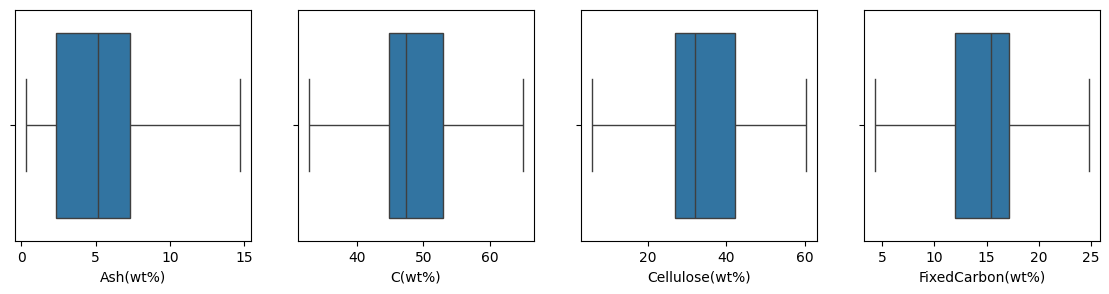

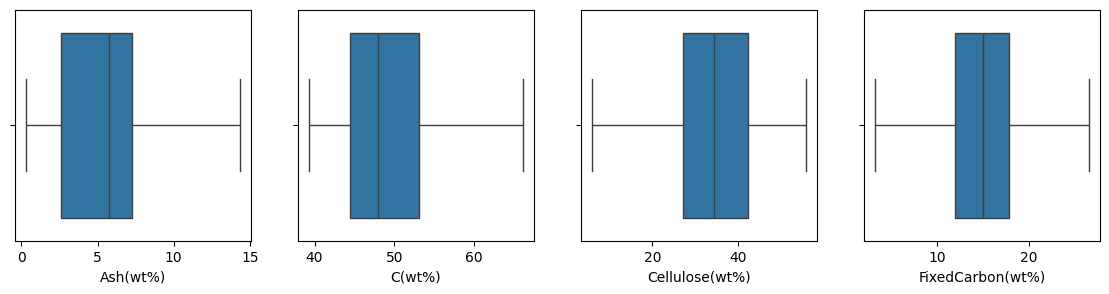

In [54]:
x_train_copy = x_train.copy()

# Apply capping using the limits stored in value_limits
for col in x_train_copy.columns:
    lower, upper = value_limits[col]
    x_train_copy[col] = x_train_copy[col].clip(lower=lower, upper=upper)

plt.figure(figsize=(14, 3))

plt.subplot(1,4,1)
sns.boxplot(x=x_train_copy['Ash(wt%)'])
plt.subplot(1,4,2)
sns.boxplot(x=x_train_copy['C(wt%)'])
plt.subplot(1,4,3)
sns.boxplot(x=x_train_copy['Cellulose(wt%)'])
plt.subplot(1,4,4)
sns.boxplot(x=x_train_copy['FixedCarbon(wt%)'])
plt.show()

x_test_capped = x_test.copy()

# Apply capping using the limits stored in value_limits
for col in x_test_capped.columns:
    lower, upper = value_limits_test[col]
    x_test_capped[col] = x_test_capped[col].clip(lower=lower, upper=upper)

plt.figure(figsize=(14, 3))

plt.subplot(1,4,1)
sns.boxplot(x=x_test_capped['Ash(wt%)'])
plt.subplot(1,4,2)
sns.boxplot(x=x_test_capped['C(wt%)'])
plt.subplot(1,4,3)
sns.boxplot(x=x_test_capped['Cellulose(wt%)'])
plt.subplot(1,4,4)
sns.boxplot(x=x_test_capped['FixedCarbon(wt%)'])
plt.show()

Investigating Constants

In [56]:
import numpy as np

# Check unique values in capped data
unique_counts = x_train_copy.nunique()
print("Unique values per feature after capping:")
print(unique_counts)

# Identify columns that became constant
constant_cols = unique_counts[unique_counts <= 1].index.tolist()
print(f"\nConstant columns to consider dropping: {constant_cols}")

### Dropping Constant Features Since `H/C` became a constant value after capping, it contains no information for the model. We will drop it from both the training and test sets.
x_train_copy.describe()
# Drop the constant column from training sets
x_train_capped = x_train_copy.drop(columns=['H/C'])

print(f"Remaining features: {list(x_train_capped.columns)}")

Unique values per feature after capping:
Ash(wt%)                     136
FixedCarbon(wt%)             133
Volatiles(wt%)               135
C(wt%)                        86
H(wt%)                        74
O(wt%)                        94
N(wt%)                       107
H/C                            1
Cellulose(wt%)               148
Hemicellulose(wt%)           161
Lignin(wt%)                  145
T(^C)                         14
HeatingRate(^C/min)           16
ParticleSize(mm)              52
FlowRate-Nitrogen(ml/min)     11
dtype: int64

Constant columns to consider dropping: ['H/C']
Remaining features: ['Ash(wt%)', 'FixedCarbon(wt%)', 'Volatiles(wt%)', 'C(wt%)', 'H(wt%)', 'O(wt%)', 'N(wt%)', 'Cellulose(wt%)', 'Hemicellulose(wt%)', 'Lignin(wt%)', 'T(^C)', 'HeatingRate(^C/min)', 'ParticleSize(mm)', 'FlowRate-Nitrogen(ml/min)']


# Feature Scaling
Standard Scaler

In [59]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
#fitting the scaler to the training set to learn the parameter
scaler.fit(x_train_capped)
#Now transform the train set
x_train_scaled=scaler.transform(x_train_capped)

#above step will return numpy array so we need to transform this to DataFrame
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train_capped.columns)
x_train_scaled.describe()

scaler.fit(x_test_capped)
x_test_scaled=scaler.transform(x_test_capped)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test_capped.columns)

#Standardization used for K Means, KNN, ANN, GD and PCA
#algo which uses distance to measure similarity which will affect when the data is having huge range difference, so we need to regularize